In [8]:
import pandas as pd
import numpy as np


In [20]:
data1=np.load("C:\\Users\\Sanjana\\Downloads\\Run355456_Dataset_jqkne.npy")
data2 = np.load("C:\\Users\\Sanjana\\Downloads\\Run357479_Dataset_iodic.npy")


In [21]:
print("shape of data1 is : ",data1.shape)
print("shape of data2 is : ",data2.shape)

shape of data1 is :  (10000, 64, 72)
shape of data2 is :  (10000, 64, 72)


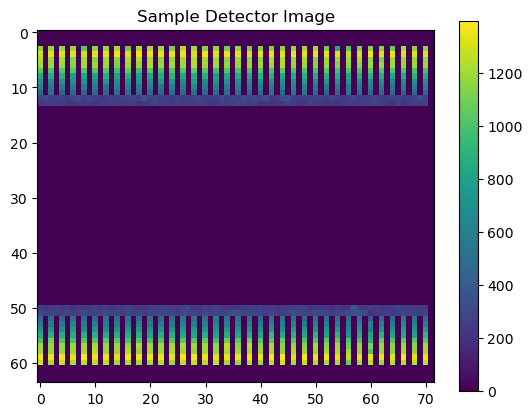

In [22]:
import matplotlib.pyplot as plt

plt.imshow(data1[0], cmap='viridis')
plt.colorbar()
plt.title("Sample Detector Image")
plt.show()


In [23]:
print("Min value:", data1.min())
print("Max value:", data1.max())
print("Mean value:", data1.mean())


Min value: 0.0
Max value: 1564.944737802157
Mean value: 157.1422515113881


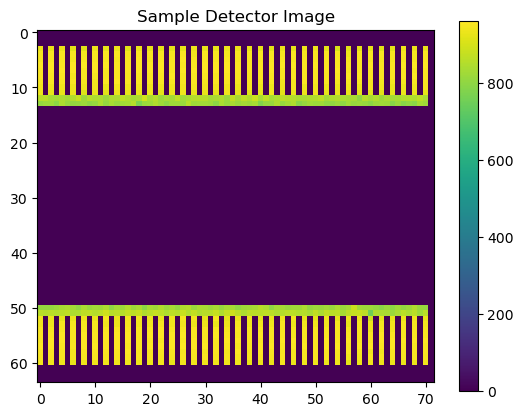

In [24]:
import matplotlib.pyplot as plt

plt.imshow(data2[0], cmap='viridis')
plt.colorbar()
plt.title("Sample Detector Image")
plt.show()


In [25]:
print("Min value:", data2.min())
print("Max value:", data2.max())
print("Mean value:", data2.mean())


Min value: 0.0
Max value: 1091.9733311864536
Mean value: 181.0825829820982


In [26]:
labels1 = np.zeros(data1.shape[0])   # 10000 zeros
labels2 = np.ones(data2.shape[0])    # 10000 ones


In [27]:
X = np.concatenate((data1, data2), axis=0)
y = np.concatenate((labels1, labels2), axis=0)

print(X.shape)  
print(y.shape)  


(20000, 64, 72)
(20000,)


In [28]:
X = X / np.max(X)


In [29]:
print("New max:", X.max())
print("New min:", X.min())


New max: 1.0
New min: 0.0


In [38]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# print(X_train.shape)
# print(X_test.shape)
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,72,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])


C:\Users\Sanjana\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 70, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 35, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 33, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 781,057 (2.98 MB)

 Trainable params: 781,057 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.9973 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 7.3679e-05
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 1.0000 - loss: 2.2714e-05 - val_accuracy: 1.0000 - val_loss: 5.5858e-06
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9998 - val_loss: 0.0014
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9999 - loss: 2.4765e-04 - val_accuracy: 1.0000 - val_loss: 1.3520e-07
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 1.0000 - loss: 3.2920e-06 - val_accuracy: 1.0000 - val_loss: 9.6411e-08
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 1.0000 - loss: 1.1269e-06 - val_accuracy: 1.0000 - val_loss: 2.8827e-08
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 1.0000 - loss: 5.9080e-07 - val_accuracy: 1.0000 - val_loss: 1.1855e-08
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 70

In [42]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 1.0000 - loss: 1.9124e-09
Test Accuracy: 1.0


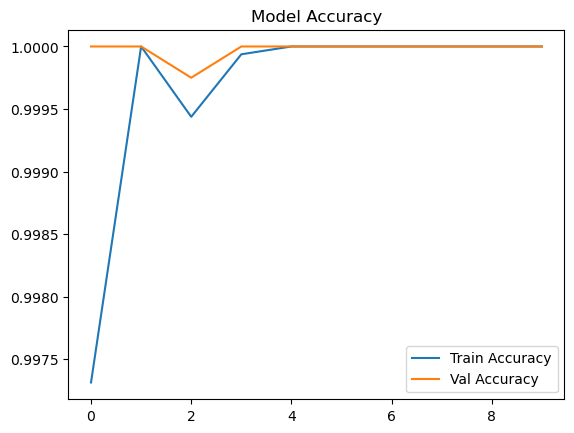

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()


In [44]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

import numpy as np
print("Unique train labels:", np.unique(y_train))
print("Unique test labels:", np.unique(y_test))


Train shape: (16000, 64, 72)
Test shape: (4000, 64, 72)
Unique train labels: [0. 1.]
Unique test labels: [0. 1.]


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


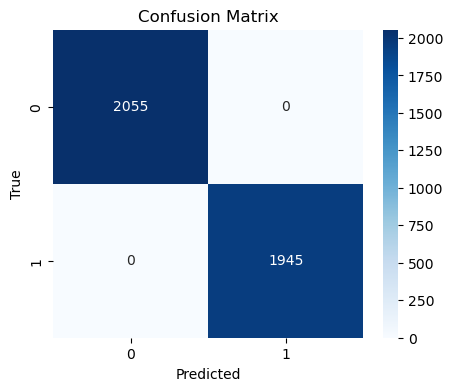

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
